In [89]:
import sys

print(sys.executable)

/home/martin/OneDrive/Projects/Portfolio/Upwork-Market-Analysis/.venv/bin/python


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("A környezet működik.")

NumPy: 2.5.1
Pandas: 3.0.5
A környezet működik.


# Job Classification

To make the exploratory analysis more meaningful, each Upwork job is assigned to one or more predefined categories using a rule-based keyword matching approach.

The categories are:

- Data Engineer
- Data Analyst
- Machine Learning
- Python Automation

Each category is matched against the job title, description, and original Upwork category. Some keywords are treated as stronger indicators and receive a higher score during classification.

In [91]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
input_file = Path(PROJECT_ROOT / "data" / "processed" / "jobs.csv")

df = pd.read_csv(input_file)

category_keywords = {
    "Data Engineer": [
        "etl",
        "data extraction",
        "extract data",
        "data pipeline",
        "pipeline",
        "data ingestion",
        "data transformation",
        "transform data",
        "data processing",
        "database",
        "database synchronization",
        "database sync",
        "postgresql",
        "mysql",
        "sql",
        "warehouse",
        "data warehouse",
        "data migration",
        "scraping",
        "web scraping",
        "api integration",
        "api",
        "sync",
        "synchronization"
        "csv",
        "excel import",
        "excel export"
        ],

    "Data Analyst": [
        "analytics",
        "analyst",
        "statistical",
        "statistics",
        "stata",
        "data analysis",
        "data analyst",
        "statistical analysis",
        "data visualization",
        "visualization",
        "dashboard",
        "power bi",
        "reporting",
        "kpi",
        "meta-analysis",
        "feature extraction",
        "e-commerce",
        "excel automation",
        "file processing",
        "file handling",
        "spreadsheet",
        "excel spreadsheet"
        ],

    "Machine Learning": [
        "machine learning",
        "artificial intelligence",
        "computer vision",
        "object detection",
        "object tracking",
        "ocr",
        "forecast",
        "forecasting",
        "predict",
        "prediction",
        "predictive model",
        "predictive modeling",
        "classification",
        "regression",
        "deep learning",
        "neural network",
        "model training",
        "llm",
        "claude",
        "openai",
        "tensorflow",
        "pytorch",
        "scikit"
        "claude api",
        "grid search",
        "benchmark",
        "benchmarking",
        "handwritten",
        "image recognition",
        "text recognition"
    ],

    "Python Automation": [
        "automation",
        "automate",
        "script",
        "scripting",
        "python script",
        "python tool",
        "desktop",
        "desktop app",
        "prototype",
        "generator",
        "report generator",
        "scheduled",
        "scheduler",
        "playwright",
        "local api",
        "file automation",
        "simulator"
        "document automation",
        "file management",
        "file organization",
        "rename files",
        "move files",
        "auto-populate"
    ]

}

double_keywords = {
    "Data Engineer": [
        "etl",
        "data pipeline",
        "data ingestion",
        "data warehouse",
        "data migration",
        "database synchronization",
        "database sync",
        "web scraping",
        "api integration"
    ],

    "Data Analyst": [
        "data analysis",
        "data analyst",
        "statistical analysis",
        "data visualization",
        "power bi",
        "meta-analysis"
    ],

    "Machine Learning": [
        "machine learning",
        "artificial intelligence",
        "computer vision",
        "object detection",
        "object tracking",
        "predictive model",
        "predictive modeling",
        "deep learning",
        "neural network",
        "model training",
        "grid search"
    ],

    "Python Automation": [
        "python script",
        "python tool",
        "desktop app",
        "report generator",
        "file automation",
        "document automation",
        "file management",
        "file organization",
        "local api"
    ]
}

minimum_matches = 2

def classify_job(row, log_file):
    
    text = (row["title"] + " " + row["category"] + " " + row["description"]).lower()

    matched_categories = []

    for category, keywords in category_keywords.items():
        matched_keywords = []
        match_score = 0

        for keyword in keywords:
            if keyword in text:
                matched_keywords.append(keyword)

                if keyword in double_keywords[category]:
                    match_score += 2
                else:
                    match_score += 1

        if match_score >= minimum_matches:
            matched_categories.append(category)

            print(row["title"], file=log_file)

            print(
                f"{category}: {matched_keywords} (Score: {match_score})",
                file=log_file
            )

            print("-" * 50, file=log_file)

        else:
            print(row["title"], file=log_file)

            print(
                f"{category}: No matches found (Score: {match_score})",
                file=log_file
            )

            print("-" * 50, file=log_file)

    
    return matched_categories if matched_categories else ["Other"]

log_file = open(Path(PROJECT_ROOT / "data" / "exports" / "debug" / "classification_log.txt"), "w", encoding="utf-8")

df["job_classes"] = df.apply(lambda row: classify_job(row, log_file), axis=1)

log_file.close()

output_file = Path(PROJECT_ROOT / "data" / "exports" / "tables" / "jobs_classified.csv")
df.to_csv(output_file, index=False, encoding="utf-8")

df[["title", "job_classes"]] 


,title,job_classes
0,Looking for a Data Scientist For Upcoming Proj...,[Machine Learning]
1,Data Extraction and Analysis Specialist,"[Data Engineer, Machine Learning]"
2,Looking for a Data Scientist For Upcoming Proj...,[Machine Learning]
3,Data Analyst for Multi‑Sensor Building Thermal...,[Data Analyst]
4,Python script to clean messy sales CSV and gen...,"[Data Engineer, Python Automation]"
5,"Dataset Collection (Images, Text) - with Pytho...",[Data Engineer]
6,Re-extraction of data for a meta-analysis - Da...,"[Data Engineer, Data Analyst]"
7,Data Analyst with Power BI and Excel,[Data Analyst]
8,Full-time Data Analyst for fast-growing creato...,[Data Analyst]
9,Product Categorization/Taxonomy tagging,"[Data Analyst, Machine Learning, Python Automa..."


## Summary

Jobs were classified using a rule-based keyword matching system.

- Multiple categories can be assigned to the same job.
- Some keywords are treated as stronger indicators and contribute a higher score.
- Jobs that did not reach the minimum score for any category were labeled as **Other** instead of forcing a potentially incorrect classification.

This approach provides transparent and interpretable classifications while acknowledging the limitations of a rule-based system.

# Research Question 1

## Which project types are the most common within each job category?

### Methodology

The distribution of project types is analyzed separately for each predefined job
category.

For every category, both absolute frequencies and relative percentages are
calculated. The results are summarized in tables and visualized using bar
charts to enable comparison between different categories.

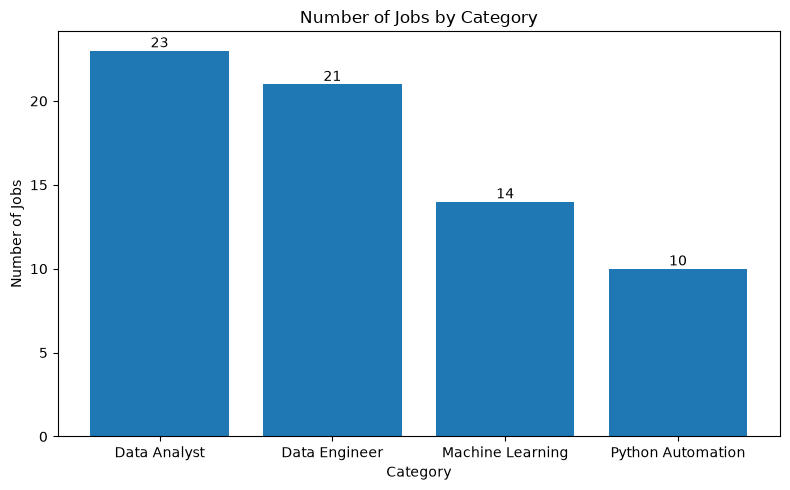

In [92]:
category_dfs = {}

for category in category_keywords.keys():
    category_dfs[category] = df[
        df["job_classes"].apply(lambda classes: category in classes)
        ]

category_counts = {}

for category, category_df in category_dfs.items():
    category_counts[category] = len(category_df)

category_counts_df = pd.DataFrame(
    category_counts.items(), columns=["Category", "Number of Jobs"]
)

category_counts_df = category_counts_df.sort_values(
    by="Number of Jobs",
    ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    category_counts_df["Category"],
    category_counts_df["Number of Jobs"]
)

plt.title("Number of Jobs by Category")
plt.xlabel("Category")
plt.ylabel("Number of Jobs")
plt.tight_layout()

for bar in bars:

    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    plt.text(
        x,
        y,
        y,
        ha = "center",
        va = "bottom"
    )

plt.savefig(
    PROJECT_ROOT / "figures" / "research_question_1" / "number_of_jobs_by_category.png"
)

plt.show()


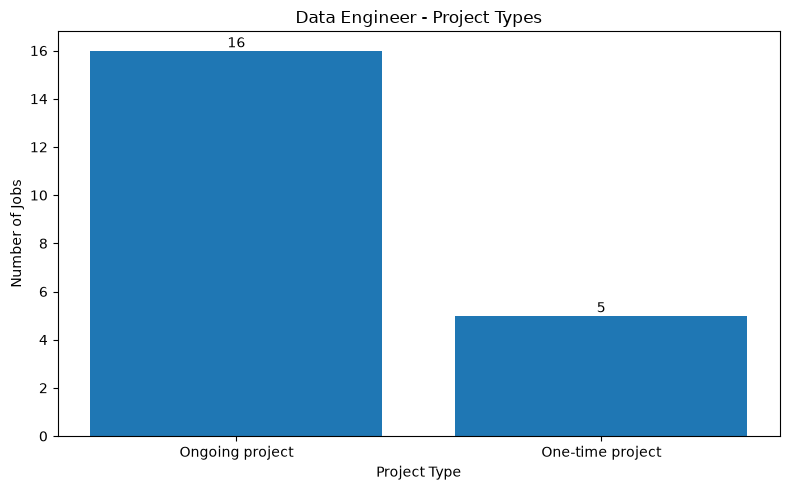

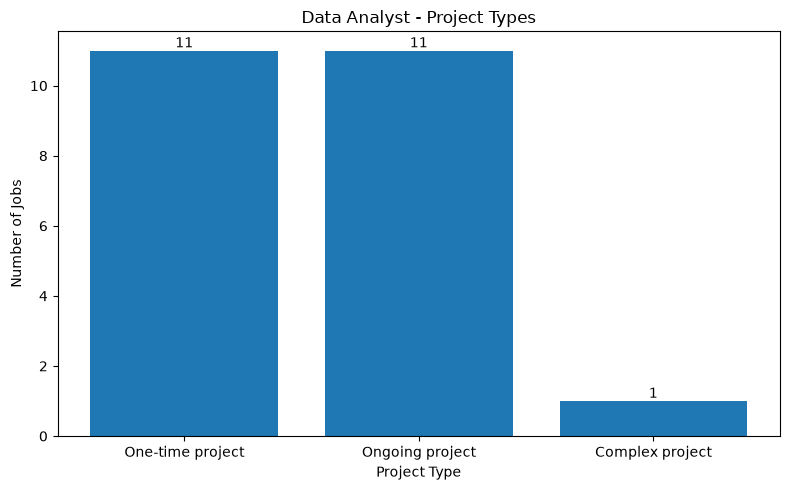

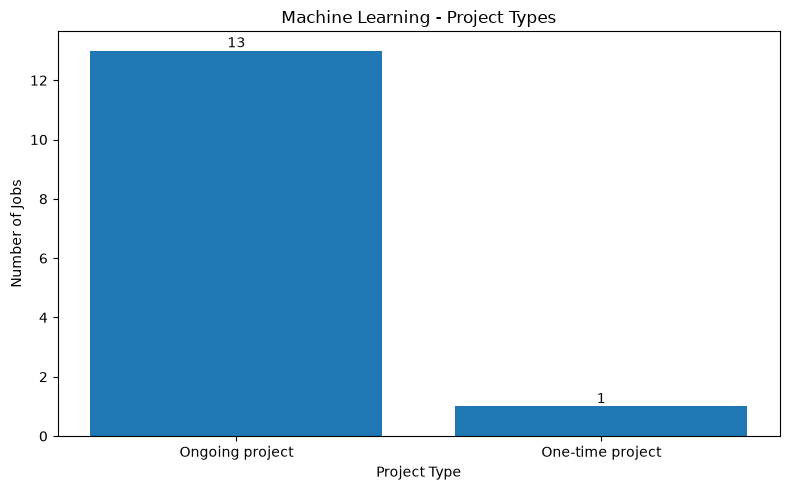

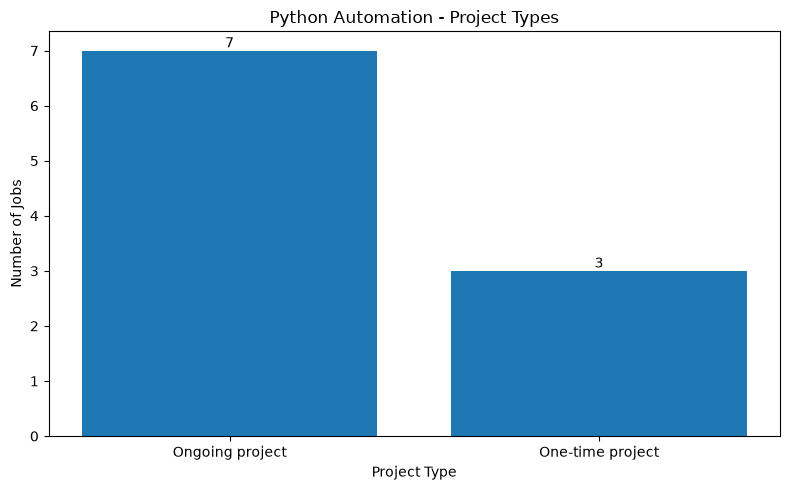

In [93]:
project_type_by_category = {}

for category, category_df in category_dfs.items():
    project_type_counts = category_df["project_type"].value_counts()
    project_type_by_category[category] = project_type_counts


for category, counts in project_type_by_category.items():

    plt.figure(figsize=(8, 5))

    bars = plt.bar(
        counts.index,
        counts.values
    )

    plt.title(f"{category} - Project Types")
    plt.xlabel("Project Type")
    plt.ylabel("Number of Jobs")
    plt.xticks(rotation=0)

    for bar in bars:

        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()

        plt.text(
            x,
            y,
            y,
            ha = "center",
            va = "bottom"
        )

    plt.tight_layout()

    filename = category.lower().replace(" ", "_")
    plt.savefig(
        PROJECT_ROOT / "figures" / "research_question_1" / f"{filename}_project_types.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



In [94]:
summary_rows = []

for category, category_df in category_dfs.items():

    counts = category_df["project_type"].value_counts()

    percentages = round(
        counts / counts.sum() * 100,
        2
    )

    summary_rows.append({
        "Category": category,

        "Ongoing Count": counts.get("Ongoing project", 0),
        "Ongoing %": percentages.get("Ongoing project", 0),

        "One-time Count": counts.get("One-time project", 0),
        "One-time %": percentages.get("One-time project", 0),

        "Complex Count": counts.get("Complex project", 0),
        "Complex %": percentages.get("Complex project", 0)

    })

summary_df = pd.DataFrame(summary_rows)

output_file_2 = Path(PROJECT_ROOT / "data" / "exports" / "tables" / "project_type_summary.csv")

summary_df.to_csv(output_file_2, index=False)



## Summary

The analysis shows that project type distributions differ across job categories.

Machine Learning and Data Engineering positions are predominantly ongoing
projects, suggesting that these roles typically require longer-term collaboration.
In contrast, Data Analyst positions are more evenly distributed between ongoing
and one-time projects, while Python Automation jobs occupy an intermediate
position.

These findings provide an initial overview of project characteristics and serve
as a foundation for the following analyses of requested technologies, Python
libraries, and technical skills.

# Research Question 2

## Which Python packages are requested most frequently?

### Methodology

A predefined list of Python libraries is searched within the title, description,
category, and skills fields of each job posting.

Each library is counted at most once per job. Frequencies are calculated
separately for every job category to reveal differences in technical demand.

In [95]:
package_aliases = {
    "Pandas": [
        "pandas"
    ],

    "NumPy": [
        "numpy"
    ],

    "Matplotlib": [
        "matplotlib"
    ],

    "Seaborn": [
        "seaborn"
    ],

    "Plotly": [
        "plotly"
    ],

    "scikit-learn": [
        "scikit-learn",
        "sklearn"
    ],

    "scikit-image": [
        "scikit-image",
        "skimage"
    ],

    "Shapely": [
        "shapely"
    ],

    "Selenium": [
        "selenium"
    ],

    "Playwright": [
        "playwright"
    ],

    "Django": [
        "django"
    ],

    "OpenCV": [
        "opencv",
        "cv2"
    ],

    "XGBoost": [
        "xgboost"
    ],

    "LightGBM": [
        "lightgbm"
    ]
}

In [96]:
def find_python_packages(row, log_file):
   
    text = (row["title"] + " " + row["category"] + " " + row["mandatory_skills"] + " " + row["description"]).lower()

    found_packages = []

    for package, aliases in package_aliases.items():

        if any(alias in text for alias in aliases):
            found_packages.append(package)

    if found_packages:
        print(row["title"], file=log_file)
        print(f"Found packages: {found_packages}", file=log_file)
        print("-" * 50, file=log_file)
    else:
        print(row["title"], file=log_file)
        print("No packages found", file=log_file)
        print("-" * 50, file=log_file)

    return found_packages

log_file = open(Path(PROJECT_ROOT / "data" / "exports" / "debug" / "python_packages_log.txt"), "w", encoding="utf-8")
df["python_packages"] = df.apply(lambda row: find_python_packages(row, log_file), axis=1)
log_file.close()

df[["title", "python_packages"]]

,title,python_packages
0,Looking for a Data Scientist For Upcoming Proj...,"[Pandas, NumPy, Matplotlib]"
1,Data Extraction and Analysis Specialist,[]
2,Looking for a Data Scientist For Upcoming Proj...,"[Pandas, NumPy, Matplotlib]"
3,Data Analyst for Multi‑Sensor Building Thermal...,"[Pandas, NumPy, Matplotlib, Seaborn, Plotly]"
4,Python script to clean messy sales CSV and gen...,[Pandas]
5,"Dataset Collection (Images, Text) - with Pytho...",[Pandas]
6,Re-extraction of data for a meta-analysis - Da...,[]
7,Data Analyst with Power BI and Excel,[]
8,Full-time Data Analyst for fast-growing creato...,[]
9,Product Categorization/Taxonomy tagging,[Pandas]


In [97]:
package_counts = df["python_packages"].explode().value_counts().sort_values(ascending=False)

package_summary = pd.DataFrame(index=package_counts.index)

package_summary["Count"] = package_counts

package_summary["Job %"] = round(package_counts / len(df) * 100, 2)

category_dfs = {}

for category in category_keywords.keys():
    category_dfs[category] = df[
        df["job_classes"].apply(lambda classes: category in classes)
    ]

for category, category_df in category_dfs.items():
    category_package_counts = category_df["python_packages"].explode().value_counts()
    package_summary[f"{category} Count"] = category_package_counts
    package_summary[f"{category} Job %"] = round(category_package_counts / len(category_df) * 100, 2)
    category_df

count_columns = [col for col in package_summary.columns if "Count" in col]
percentage_columns = [col for col in package_summary.columns if "%" in col]

package_summary[count_columns] = package_summary[count_columns].fillna(0).astype(int)
package_summary[percentage_columns] = package_summary[percentage_columns].fillna(0).astype(float)

output_file_3 = Path(PROJECT_ROOT / "data" / "exports" / "tables" / "python_package_summary.csv")
package_summary.to_csv(output_file_3)

package_summary

,Count,Job %,Data Engineer Count,Data Engineer Job %,Data Analyst Count,Data Analyst Job %,Machine Learning Count,Machine Learning Job %,Python Automation Count,Python Automation Job %
python_packages,,,,,,,,,,
Pandas,14,31.82,7,33.33,9,39.13,5,35.71,3,30.0
NumPy,7,15.91,1,4.76,4,17.39,4,28.57,0,0.0
Matplotlib,4,9.09,0,0.00,1,4.35,2,14.29,0,0.0
scikit-learn,2,4.55,1,4.76,2,8.70,2,14.29,0,0.0
Seaborn,1,2.27,0,0.00,1,4.35,0,0.00,0,0.0
Plotly,1,2.27,0,0.00,1,4.35,0,0.00,0,0.0
Django,1,2.27,1,4.76,1,4.35,1,7.14,0,0.0
scikit-image,1,2.27,0,0.00,0,0.00,0,0.00,0,0.0
Shapely,1,2.27,0,0.00,0,0.00,0,0.00,0,0.0


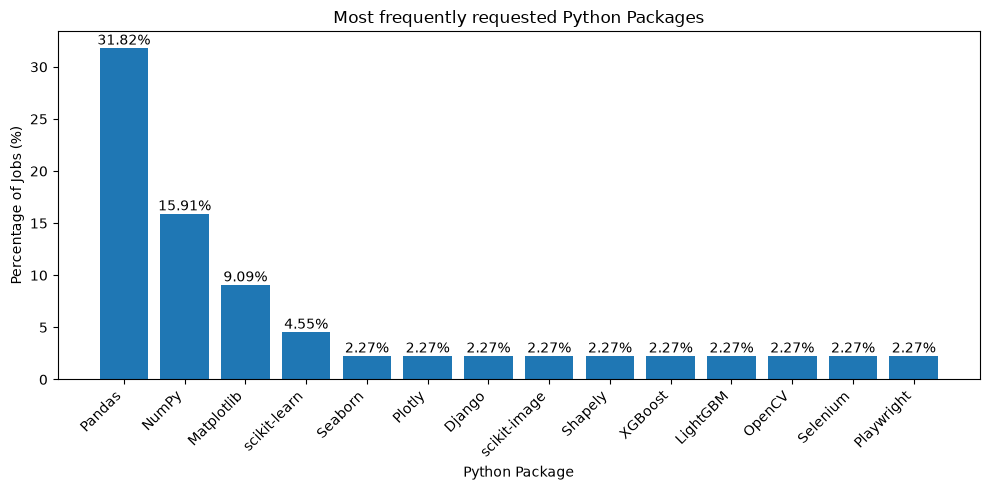

In [98]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    package_summary.index,
    package_summary["Job %"]
)

plt.title("Most frequently requested Python Packages")
plt.xlabel("Python Package")
plt.ylabel("Percentage of Jobs (%)")

plt.xticks(rotation=45, ha="right")

for bar in bars:

    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    plt.text(
        x,
        y,
        f"{y:.2f}%",
        ha = "center",
        va = "bottom"
    )

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "research_question_2" / "most_requested_python_packages_overall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

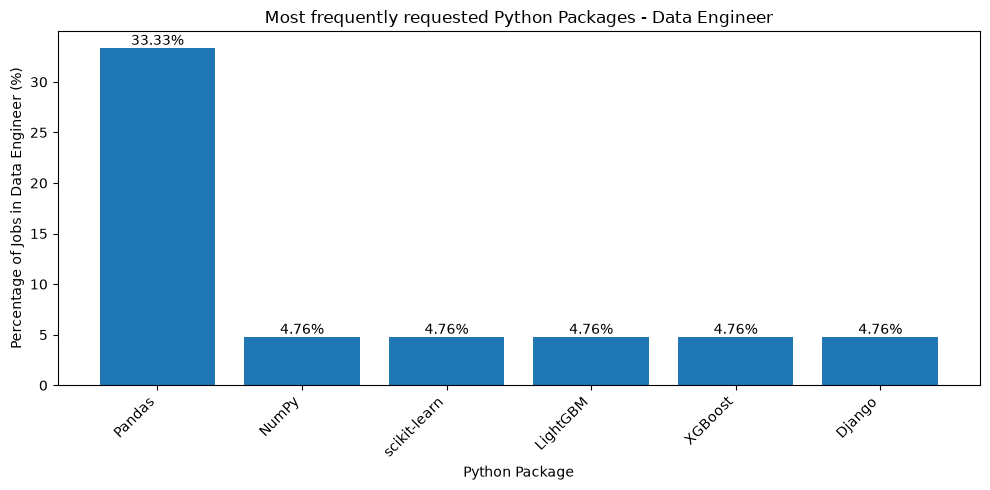

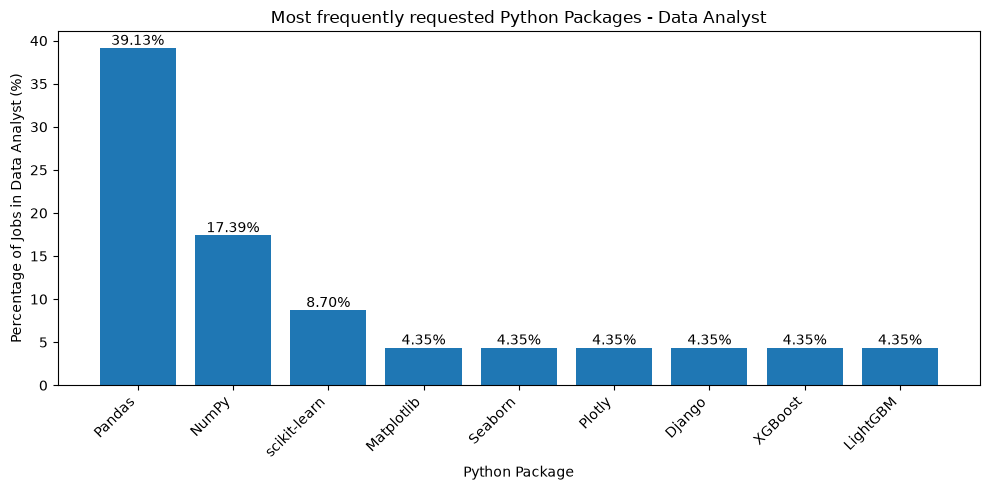

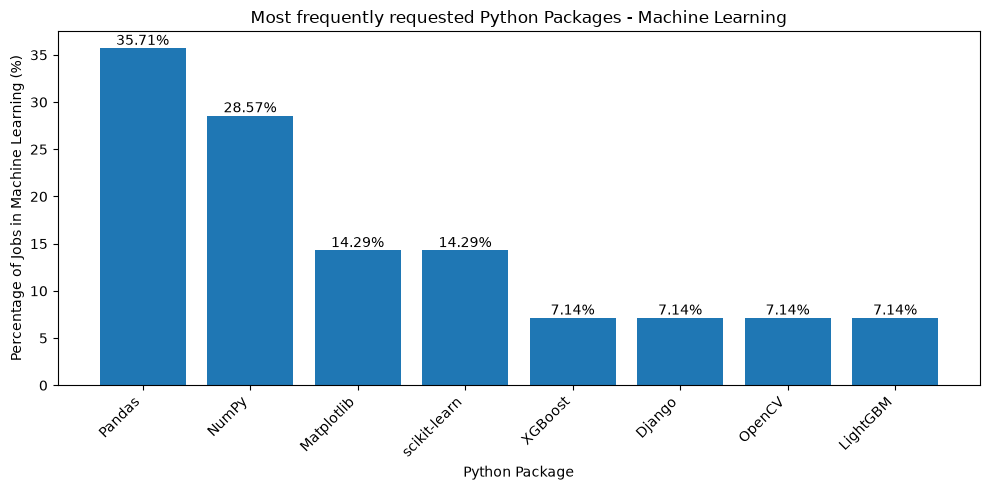

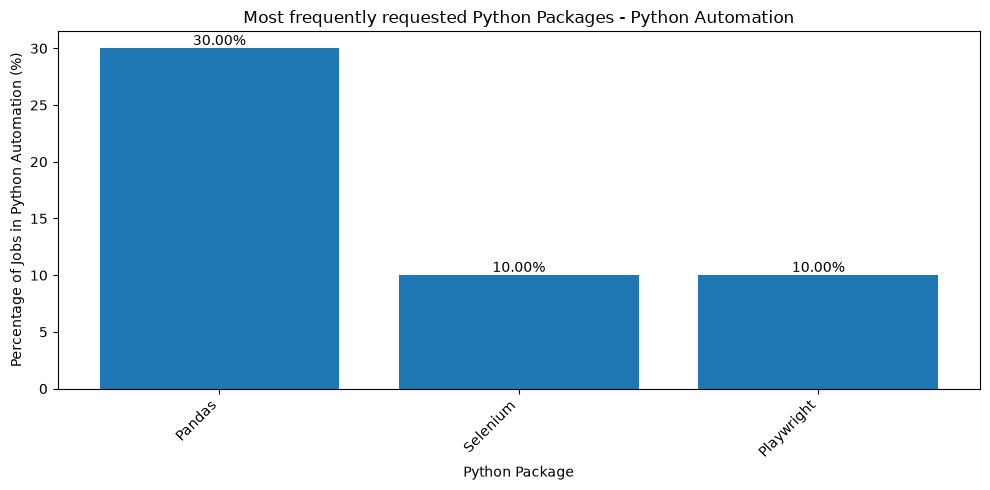

In [99]:
for category, category_df in category_dfs.items():

    plt.figure(figsize=(10, 5))

    package_summary_category = package_summary.copy().sort_values(by =f"{category} Job %", ascending=False)
    package_summary_category = package_summary_category[package_summary_category[f"{category} Job %"] > 0]

    bars = plt.bar(
        package_summary_category.index,
        package_summary_category[f"{category} Job %"]
    )

    plt.title(f"Most frequently requested Python Packages - {category}")
    plt.xlabel("Python Package")
    plt.ylabel(f"Percentage of Jobs in {category} (%)")

    plt.xticks(rotation=45, ha="right")

    for bar in bars:

        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()

        plt.text(
            x,
            y,
            f"{y:.2f}%",
            ha = "center",
            va = "bottom"
        )

    plt.tight_layout()

    filename = category.lower().replace(" ", "_")
    plt.savefig(
        PROJECT_ROOT / "figures" / "research_question_2" / f"{filename}_most_requested_python_packages.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Summary

The analysis shows that Pandas is the most frequently requested Python package across the collected freelance job postings, appearing in nearly one-third of all projects. NumPy is the second most common package, followed by Matplotlib and scikit-learn, indicating that data manipulation, numerical computing, visualization, and machine learning form the core Python ecosystem required in the analyzed market.

The category-specific analysis highlights clear differences between project types. Data Analyst projects primarily require data analysis and visualization libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Plotly. Machine Learning projects introduce specialized machine learning packages, including scikit-learn, XGBoost, LightGBM, and OpenCV. In contrast, Python Automation projects focus mainly on automation frameworks such as Selenium and Playwright, while still relying on Pandas for data processing.

These results provide an overview of the Python ecosystem most commonly requested in the analyzed freelance projects and help identify the libraries that should be prioritized when building a practical portfolio.

# Research Question 3

## Which technologies and tools appear most often?

### Methodology

A predefined dictionary of technologies and tools was created, including common
aliases and alternative names for each technology (e.g., "PostgreSQL" and
"Postgres", or "Apache Spark" and "PySpark").

For each job posting, the title, category, mandatory skills, and preferred
qualifications were combined into a single searchable text. Technologies were
identified using case-insensitive regular expression matching with word
boundaries to minimize false positive matches.

Each technology was counted at most once per job posting, regardless of how many
times it appeared in the advertisement. The detected technologies were stored as
a list for each posting.

Finally, frequencies were calculated for the entire dataset and separately for
each job category. The results were expressed as the percentage of job postings
requesting each technology and visualized using bar charts and a heatmap to
highlight differences between job categories.

In [100]:
technology_aliases = {

    # Programming Languages
    "Python": ["python"],
    "SQL": ["sql"],
    "R": ["r", "r language", "r programming"],
    "Java": ["java"],
    "JavaScript": [
        "javascript",
        "node.js",
        "nodejs"
    ],
    "TypeScript": ["typescript"],
    "C#": ["c#", ".net", "asp.net"],
    "Go": ["golang", "go language"],

    # Databases
    "PostgreSQL": ["postgresql", "postgres"],
    "MySQL": ["mysql"],
    "SQLite": ["sqlite"],
    "Microsoft SQL Server": [
        "microsoft sql server",
        "sql server"
    ],
    "MongoDB": ["mongodb"],
    "Redis": ["redis"],
    "Qdrant": ["qdrant"],

    # Cloud Platforms
    "AWS": ["aws", "amazon web services"],
    "Azure": ["azure", "microsoft azure"],
    "Google Cloud": ["google cloud", "gcp"],

    # Data Engineering
    "Apache Spark": [
        "apache spark",
        "pyspark"
    ],
    "Apache Airflow": [
        "apache airflow",
        "airflow"
    ],
    "Apache Kafka": [
        "apache kafka",
        "kafka"
    ],
    "Hadoop": ["hadoop"],

    # BI & Analytics
    "Power BI": ["power bi"],
    "Tableau": ["tableau"],
    "Excel": [
        "excel",
        "microsoft excel"
    ],
    "Google Sheets": ["google sheets"],
    "Stata": ["stata"],
    "IBM SPSS": [
        "ibm spss",
        "spss"
    ],
    "SAS": ["sas"],

    # APIs & Web
    "REST API": [
        "rest api",
        "rest apis",
        "restful api"
    ],
    "FastAPI": ["fastapi"],
    "Flask": ["flask"],

    # DevOps & Version Control
    "Docker": ["docker"],
    "Kubernetes": [
        "kubernetes",
        "k8s"
    ],
    "Git": [
        "git",
        "version control"
    ],
    "GitHub": ["github"],
    "Linux": ["linux"],
    "CI/CD": [
        "ci/cd",
        "continuous integration"
    ],

    # AI Tools
    "OpenAI": [
        "openai",
        "openai api"
    ],
    "Claude": [
        "claude",
        "claude api"
    ],
    "Gemini": [
        "gemini",
        "gemini api"
    ],
    "LangChain": ["langchain"],

    # Automation
    "Selenium": ["selenium"],
    "Playwright": ["playwright"],
    "AdsPower": ["adspower"],

    # GUI Frameworks
    "Tkinter": [
        "tkinter",
        "customtkinter"
    ],

    # Computer Vision
    "OCR": ["ocr"]
}

In [101]:
import re

def contains_alias(text, alias):
    pattern = rf"(?<!\w){re.escape(alias.lower())}(?!\w)"
    return re.search(pattern, text) is not None

def find_technologies(row, log_file):
    text = " ".join([
        str(row["title"] if pd.notna(row["title"]) else ""),
        str(row["category"] if pd.notna(row["category"]) else ""),
        str(row["mandatory_skills"] if pd.notna(row["mandatory_skills"]) else ""),
        str(row["description"] if pd.notna(row["description"]) else ""),
        str(row["preferred_qualifications"] if pd.notna(row["preferred_qualifications"]) else "")
    ]).lower()

    found_technologies = []

    for technology, aliases in technology_aliases.items():

        if any(contains_alias(text, alias) for alias in aliases):
            found_technologies.append(technology)

    if found_technologies:
        print(row["title"], file=log_file)
        print(f"Found technologies: {found_technologies}", file=log_file)
        print("-" * 50, file=log_file)
    else:
        print(row["title"], file=log_file)
        print("No technologies found", file=log_file)
        print("-" * 50, file=log_file) 

    return found_technologies

log_file = open(Path(PROJECT_ROOT / "data" / "exports" / "debug" / "technologies_log.txt"), "w", encoding="utf-8")
df["technologies"] = df.apply(lambda row: find_technologies(row, log_file), axis=1)
log_file.close()

df[["title", "technologies"]]

,title,technologies
0,Looking for a Data Scientist For Upcoming Proj...,[Python]
1,Data Extraction and Analysis Specialist,"[Python, SQL, IBM SPSS]"
2,Looking for a Data Scientist For Upcoming Proj...,[Python]
3,Data Analyst for Multi‑Sensor Building Thermal...,[Python]
4,Python script to clean messy sales CSV and gen...,"[Python, Excel]"
5,"Dataset Collection (Images, Text) - with Pytho...","[Python, OpenAI]"
6,Re-extraction of data for a meta-analysis - Da...,[]
7,Data Analyst with Power BI and Excel,"[Power BI, Tableau, Excel, IBM SPSS]"
8,Full-time Data Analyst for fast-growing creato...,"[Python, SQL]"
9,Product Categorization/Taxonomy tagging,[Python]


In [102]:
technology_counts = df["technologies"].explode().value_counts().sort_values(ascending=True)

technology_summary = pd.DataFrame(index=technology_counts.index)

technology_summary["Count"] = technology_counts
technology_summary["Job %"] = round(technology_counts / len(df) * 100, 2)

category_dfs = {}

for category in category_keywords.keys():
    category_dfs[category] = df[
        df["job_classes"].apply(lambda classes: category in classes)
        ]

for category, category_df in category_dfs.items():
    category_technology_counts = category_df["technologies"].explode().value_counts()
    technology_summary[f"{category} Count"] = category_technology_counts
    technology_summary[f"{category} Job %"] = round(category_technology_counts / len(category_df) * 100, 2)

count_columns = [col for col in technology_summary.columns if "Count" in col]
percentage_columns = [col for col in technology_summary.columns if "%" in col]

technology_summary[count_columns] = technology_summary[count_columns].fillna(0).astype(int)
technology_summary[percentage_columns] = technology_summary[percentage_columns].fillna(0).astype(float)

output_file_4 = Path(PROJECT_ROOT / "data" / "exports" / "tables" / "technology_summary.csv")
technology_summary.to_csv(output_file_4)

technology_summary 

,Count,Job %,Data Engineer Count,Data Engineer Job %,Data Analyst Count,Data Analyst Job %,Machine Learning Count,Machine Learning Job %,Python Automation Count,Python Automation Job %
technologies,,,,,,,,,,
R,1,2.27,0,0.00,1,4.35,0,0.00,0,0.0
PostgreSQL,1,2.27,1,4.76,1,4.35,1,7.14,0,0.0
REST API,1,2.27,1,4.76,1,4.35,0,0.00,1,10.0
Qdrant,1,2.27,1,4.76,0,0.00,0,0.00,0,0.0
C#,1,2.27,0,0.00,0,0.00,0,0.00,0,0.0
Tkinter,1,2.27,0,0.00,0,0.00,0,0.00,1,10.0
AdsPower,1,2.27,0,0.00,0,0.00,0,0.00,1,10.0
Playwright,1,2.27,0,0.00,0,0.00,0,0.00,1,10.0
Selenium,1,2.27,0,0.00,0,0.00,0,0.00,1,10.0


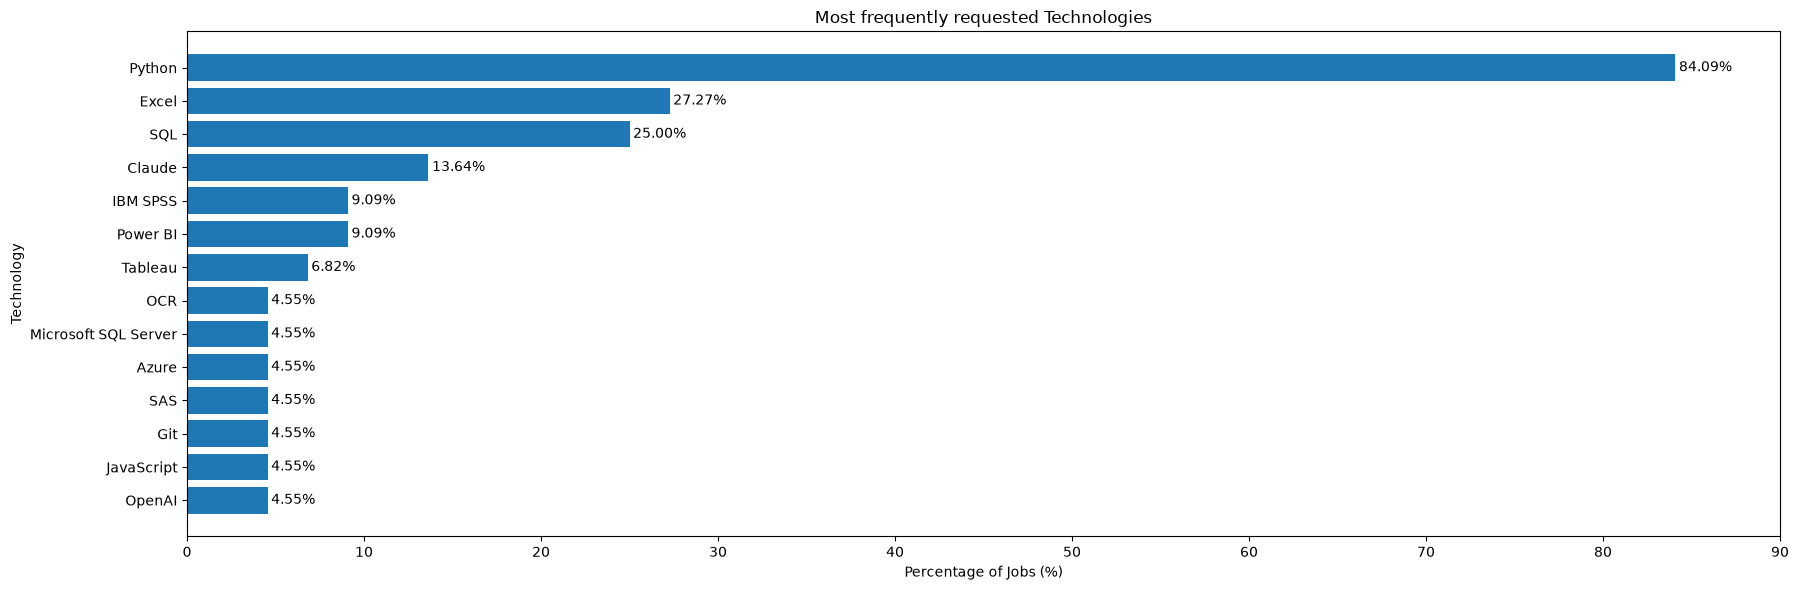

In [103]:
technology_summary_plot = technology_summary[
    technology_summary["Count"] >= 2
]

plt.figure(figsize=(18, 6))

bars = plt.barh(
    technology_summary_plot.index,
    technology_summary_plot["Job %"]
)

plt.title("Most frequently requested Technologies")

plt.ylabel("Technology")
plt.xlabel("Percentage of Jobs (%)")

for bar in bars:

    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    plt.text(
        x + 0.2,
        y,
        f"{x:.2f}%",
        ha = "left",
        va = "center"
    )

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "research_question_3" / "most_requested_technologies_overall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.xlim(0, 90)

plt.show()

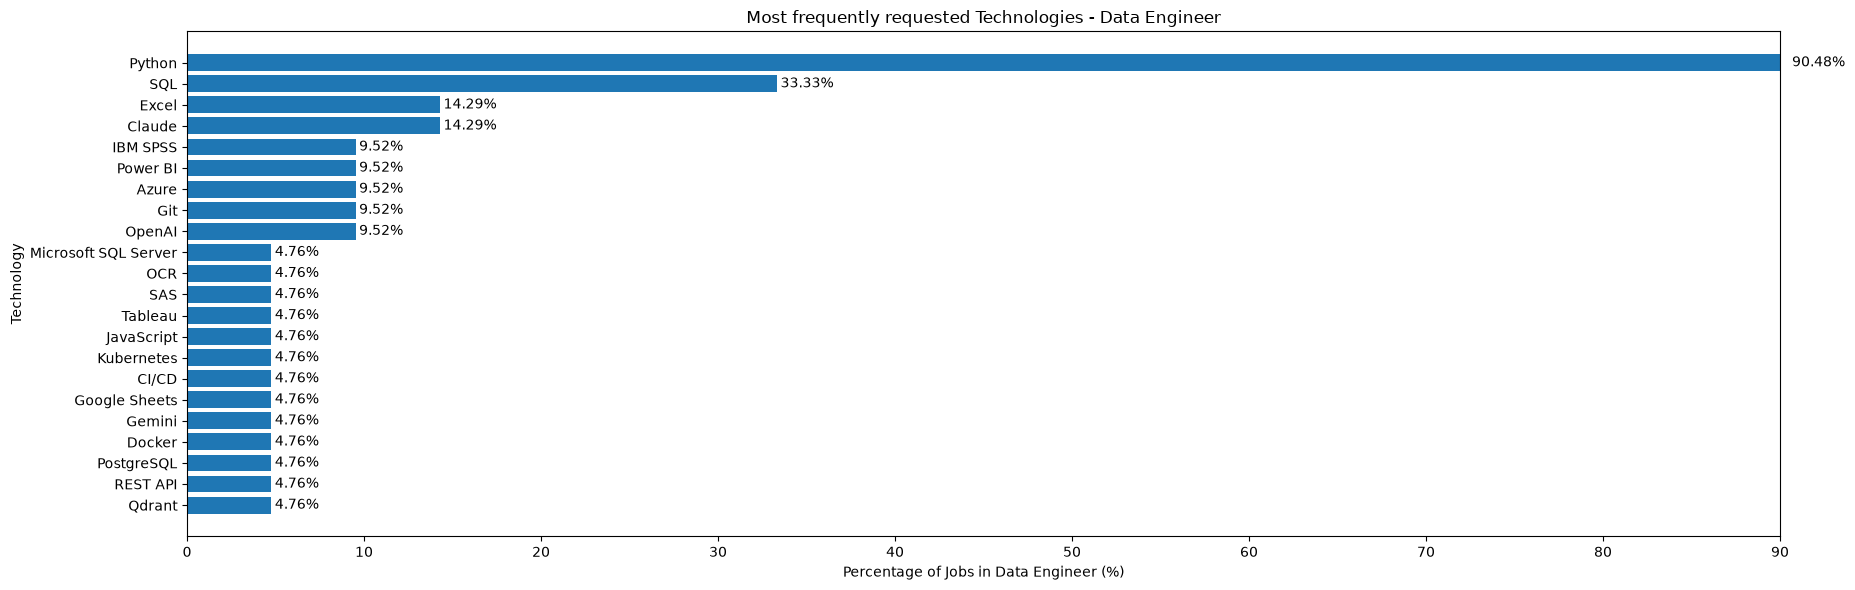

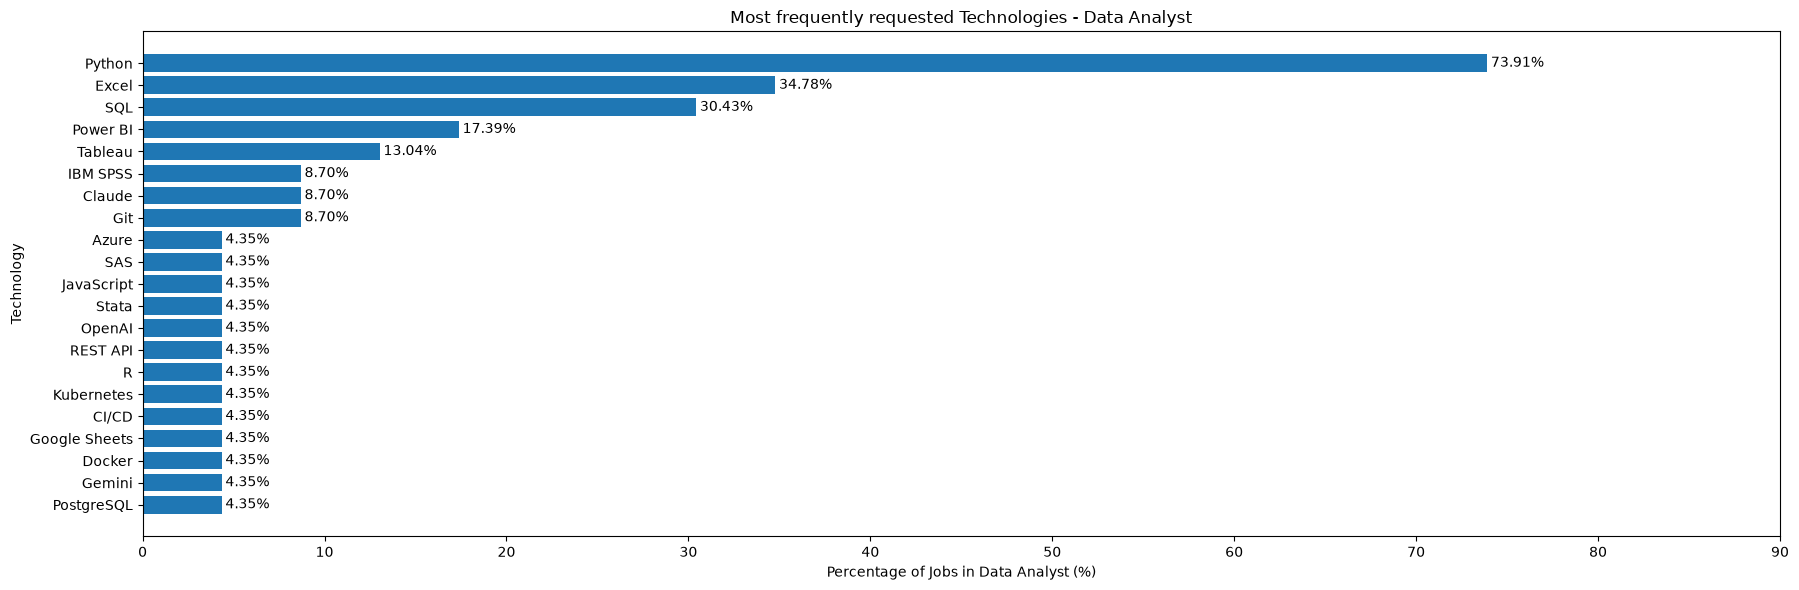

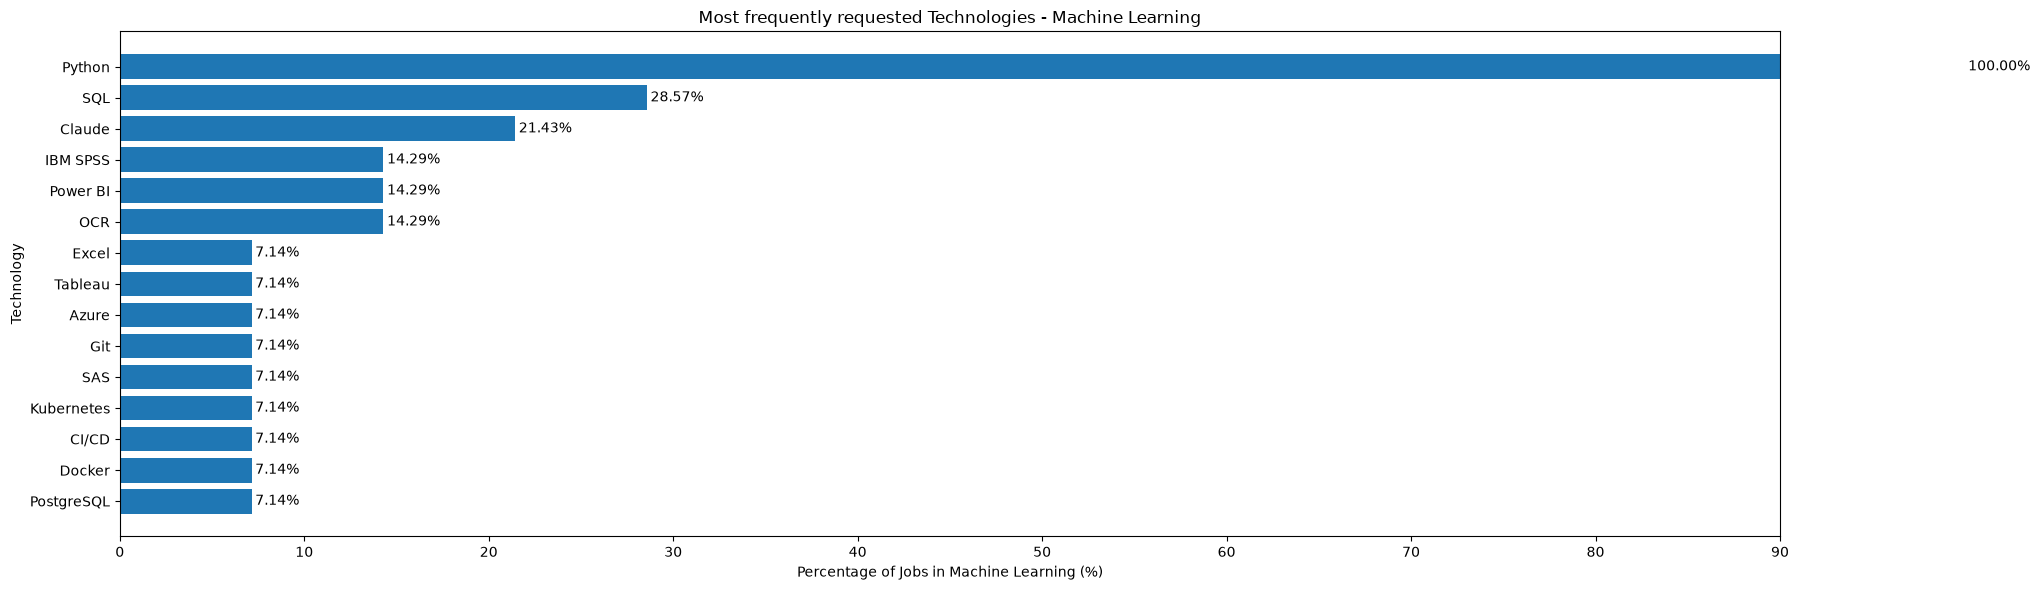

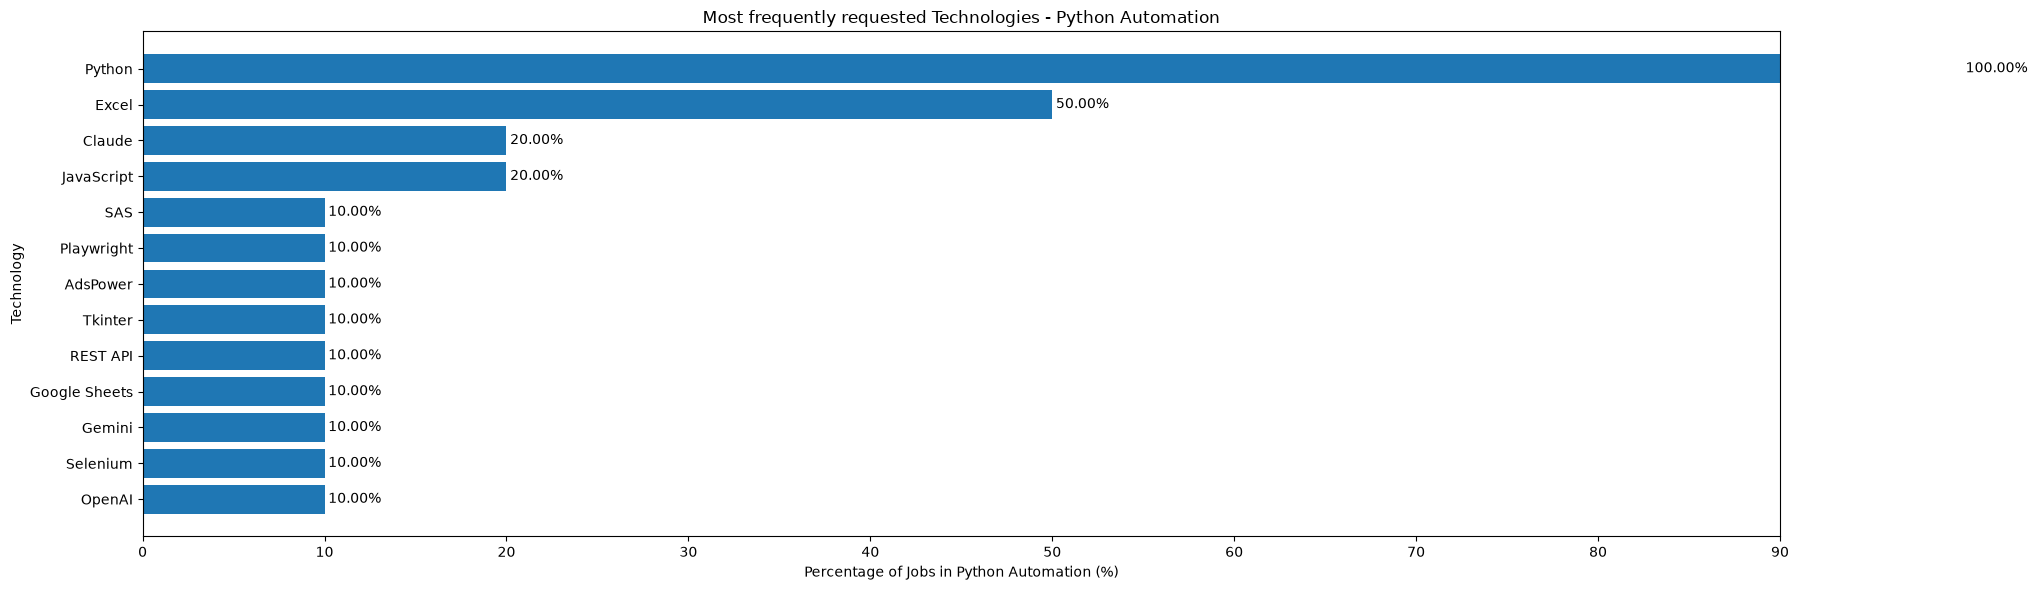

In [104]:
for category, category_df in category_dfs.items():

    technology_summary_category = technology_summary.copy().sort_values(by=f"{category} Job %", ascending=True)
    technology_summary_category_plot = technology_summary_category[technology_summary_category[f"{category} Job %"] > 0]

    plt.figure(figsize=(18, 6))

    bars = plt.barh(
        technology_summary_category_plot.index,
        technology_summary_category_plot[f"{category} Job %"]
    )

    plt.title(f"Most frequently requested Technologies - {category}")
    plt.ylabel("Technology")
    plt.xlabel(f"Percentage of Jobs in {category} (%)")

    for bar in bars:
        
        x = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2

        plt.text(
            x + 0.2,
            y,
            f"{x:.2f}%",
            ha = "left",
            va = "center"
        )

    plt.tight_layout()

    filename = category.lower().replace(" ", "_")
    plt.savefig(
        PROJECT_ROOT / "figures" / "research_question_3" / f"{filename}_most_requested_technologies.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.xlim(0, 90)

    plt.show()

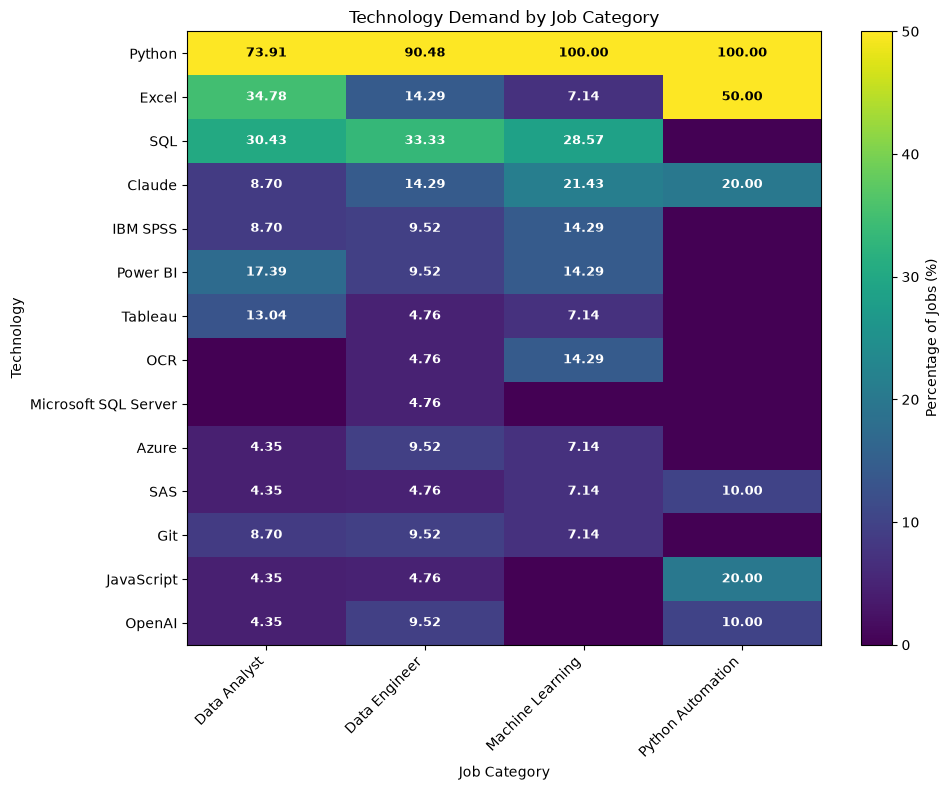

In [124]:
heatmap_data = technology_summary[
    [
        "Data Analyst Job %",
        "Data Engineer Job %",
        "Machine Learning Job %",
        "Python Automation Job %"
    ]
].copy()

heatmap_data.columns = [
    "Data Analyst",
    "Data Engineer",
    "Machine Learning",
    "Python Automation"
]

heatmap_data = heatmap_data[
    technology_summary["Count"] >= 2
]

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    vmin=0,
    vmax=50
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(
    heatmap_data.index
)

ax.set_title("Technology Demand by Job Category")
ax.set_xlabel("Job Category")
ax.set_ylabel("Technology")
ax.invert_yaxis()

plt.colorbar(image, ax=ax).set_label("Percentage of Jobs (%)")

threshold = heatmap_data.values.max() / 2

for row_index in range(len(heatmap_data.index)):
    for column_index in range(len(heatmap_data.columns)):

        value = float(heatmap_data.iloc[row_index, column_index])

        if value > 0:

            text_color = "white" if value < threshold else "black"

            ax.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color
            )

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "research_question_3" / "technology_heatmap_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Summary

Python was the most frequently requested technology across all analysed job categories, confirming its central role in data-related positions. SQL was the second most common technology, particularly in Data Analyst, Data Engineer, and Machine Learning roles.

The results also revealed clear differences between job categories. Data Analyst positions emphasized business intelligence tools such as Excel, Power BI, and Tableau, while Data Engineer roles focused more on database technologies and cloud platforms. Machine Learning positions showed greater demand for OCR-related technologies and AI tools, whereas Python Automation roles more frequently required JavaScript, REST APIs, and automation frameworks.

Overall, the findings indicate that although Python serves as the common foundation across all categories, the supporting technologies vary according to the specific responsibilities of each role.